# Прогнозирование активности пользователей Netflix (KDD Cup 2007)

Соревнование: KDD Cup 2007, организованное Netflix.  
Цель конкурса: предсказать аспекты поведения пользователей Netflix на основе их исторических оценок фильмов.

---

### Задача: Who Rated What in 2006 (Task1 в оригинальном соревновании)
Цель: Предсказать, оценил ли конкретный пользователь конкретный фильм в 2006 году. (бинарная классификация)

Train: (данные с 1999 по 2005 гг)
| данные | содержимое | 
| :--- | ---: |
| dataset/combined_data_*.txt   |   ['MovieID', 'UserID', 'Rating', 'Date'] |
| dataset/movie_titles_quoted.csv              |   ['MovieID', 'Year', 'Title'] |

Test: ( пары для предсказания с ответами [Ground Truth = Rating, где 0 - нет оценки, а 1-5 - есть] )
| данные | содержимое | 
| :-- | --: |
| who_rated_what_2006.txt | ['UserID', 'MovieID', 'GT'] |

---

**Формальная постановка задачи**

Для множества тестовых пар $(u_i, m_i)$ построить модель $a(u, m) \rightarrow p \in [0, 1]$, предсказывающую вероятность оценки фильма пользователем в 2006.

**Метрика качества**

$RMSE = \sqrt{\frac{1}{n}\sum (y_i - p_i)^2}$, где $y_i \in \{0, 1\}$

---

Познакомимся с решениями победителей конкурса:

| Место | RMSE | Команда / авторы | Основные методы / идеи |
| --- | --- | --- | --- |
| 1-е место | 0.256 | Hungarian Academy of Sciences (Miklos Kurucz и др.) https://www.kdd.org/exploration_files/1-task-1-winner.pdf | Комбинация: <br>прогноз числа рейтингов по фильмам и пользователям;<br>латентное разложение (SVD);<br>item-item similarity;<br>частые последовательности (association rules);<br>временные признаки и дата релиза фильмов |
| 1-й Runner-Up | 0.263 | Advanced Analytical Solutions Team (Neo Metrics) | Историческая статистика + классическое прогнозирование;<br>построение признаков поведения пользователей и фильмов;<br>логистическая регрессия/статистическая классификация |
| 2-й Runner-Up | 0.265 | Yan Liu, Zhenzhen Kou (IBM Research) | Link prediction как бинарная классификация;<br>использование признаков графа (user–movie), профилей пользователей, описания фильмов и топологии сети |

---

### 0. Загрузка моделей и матрицы интеракций

In [2]:
import numpy as np
import pandas as pd

import joblib
import scipy.sparse as sp

import implicit

import torch
import torch.nn as nn
from torch.utils.data import Dataset

/home/alex/Desktop/bmstu/kr_netflix/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class KDDDataset(Dataset):
    def __init__(self, matrix):
        self.matrix = matrix
    
    def __len__(self):
        return self.matrix.shape[0]

    def __getitem__(self, idx):
        start, end = self.matrix.indptr[idx], self.matrix.indptr[idx+1]
        indices = self.matrix.indices[start:end]
        data = self.matrix.data[start:end]
        
        row = np.zeros(self.matrix.shape[1], dtype=np.float32)
        row[indices] = data
        
        norm = np.linalg.norm(row)
        if norm > 1e-9:
            row /= norm
        return torch.from_numpy(row)

class ELSA(nn.Module):
    def __init__(self, n_items, n_factors=64):
        super().__init__()
        self.A = nn.Linear(n_items, n_factors, bias=False)
        self.B = nn.Linear(n_factors, n_items, bias=False)
    
    def forward(self, x):
        return self.B(self.A(x))


Матрица интеракций

In [5]:
X = sp.load_npz('X_matrix.npz')
dataset = KDDDataset(X)

Предобученные энкодеры для пользователей и товаров

In [6]:
user_encoder = joblib.load('user_encoder.joblib')
n_users = len(user_encoder.classes_)
item_encoder = joblib.load('item_encoder.joblib')
n_items = len(item_encoder.classes_)

Предобученные модели ELSA, ALS

In [7]:
model_elsa = ELSA(n_items)
model_elsa.load_state_dict(torch.load('elsa_model.pth'))

model_als = implicit.als.AlternatingLeastSquares().load('my_als_model.npz')
user_factors = model_als.user_factors
item_factors = model_als.item_factors

/home/alex/Desktop/bmstu/kr_netflix/.venv/lib/python3.12/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


### 1. Разведочный анализ данных (EDA)

In [1]:
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from collections import Counter, defaultdict

Функция чтения сырых данных (combined_data_*.txt)

In [3]:
def stream_combined_data(paths):
    for path in paths:
        with open('dataset/'+path, 'r') as f:
            movieid = None
            for i, line in enumerate(tqdm(f, desc=path)):
                line = line.strip()
                if line.endswith(':'):
                    movieid = line[:-1]
                else:
                    u, r, d = line.split(',')
                    yield (int(movieid), int(u), int(r), d)

paths = ['combined_data_1.txt','combined_data_2.txt','combined_data_3.txt','combined_data_4.txt']

Визуализация основных характеристик датасета:

- **Временной ряд** - динамика оценок с выделением январских периодов
- **Годовая статистика** - общая активность по годам
- **Активность пользователей** - распределение и кумулятивная доля
- **Популярность фильмов** - распределение количества оценок
- **Рейтинги** - распределение оценок 1-5

In [16]:
month_counts = defaultdict(int)
year_counts = defaultdict(int)
user_ratings_count = Counter()
movie_ratings_count = Counter()
rating_dist = Counter()

for movieid, userid, rating, date_str in stream_combined_data(paths):
    year_key = int(date_str[:4])
    month_key = date_str[:7]
    
    month_counts[month_key] += 1
    year_counts[year_key] += 1
    
    user_ratings_count[userid] += 1
    movie_ratings_count[movieid] += 1
    rating_dist[int(rating)] += 1

months_sorted = sorted(month_counts.keys())
month_vals = [month_counts[m] for m in months_sorted]
years_sorted = sorted(year_counts.keys())
year_vals = [year_counts[y] for y in years_sorted]

user_counts = list(user_ratings_count.values())
movie_counts = list(movie_ratings_count.values())

combined_data_1.txt: 24058263it [00:41, 580217.28it/s]
combined_data_2.txt: 26982302it [00:47, 569775.86it/s]
combined_data_3.txt: 22605786it [00:40, 563227.65it/s]
combined_data_4.txt: 26851926it [00:48, 556952.01it/s]


/tmp/ipykernel_33842/2718587863.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


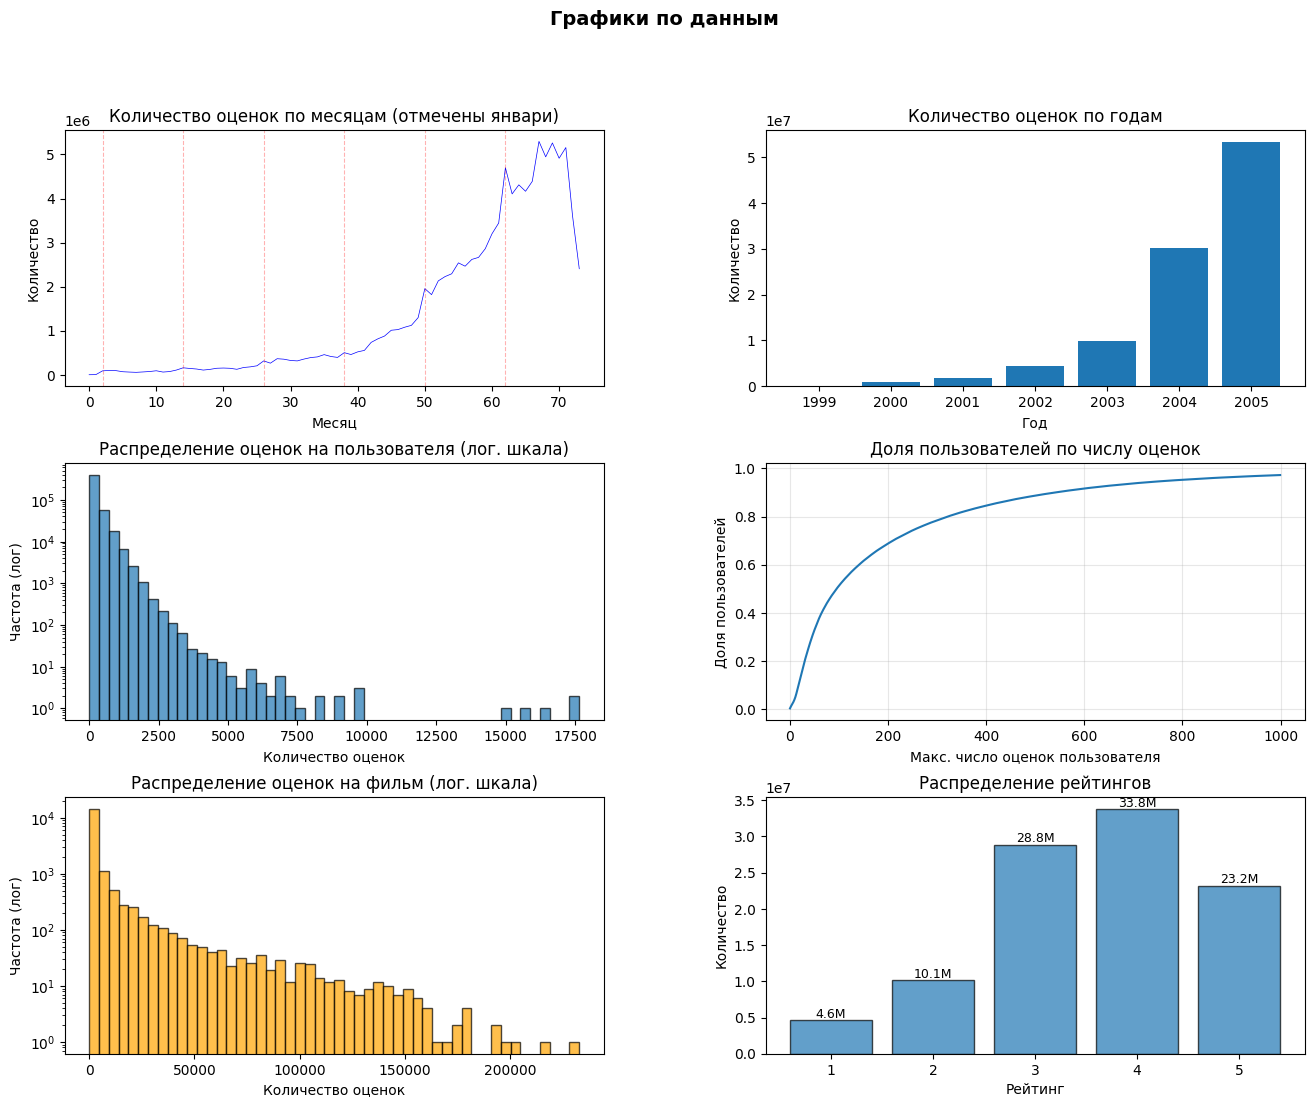

Всего оценок: 100,480,507
Уникальных пользователей: 480,189
Уникальных фильмов: 17,770
Среднее оценок на пользователя: 209.3
Среднее оценок на фильм: 5654.5


In [20]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

# 1. Оценки по месяцам
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(len(month_vals)), month_vals, 'b-', linewidth=0.5)
jan_indices = [i for i, m in enumerate(months_sorted) if m.endswith('-01')]
for idx in jan_indices:
    ax1.axvline(x=idx, color='r', linestyle='--', alpha=0.3, linewidth=0.8)
ax1.set_title('Количество оценок по месяцам (отмечены январи)')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Количество')

# 2. Оценки по годам
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(years_sorted, year_vals, width=0.8)
ax2.set_title('Количество оценок по годам')
ax2.set_xlabel('Год')
ax2.set_ylabel('Количество')

# 3. Гистограмма оценок на пользователя (log)
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(user_counts, bins=50, log=True, edgecolor='black', alpha=0.7)
ax3.set_title('Распределение оценок на пользователя (лог. шкала)')
ax3.set_xlabel('Количество оценок')
ax3.set_ylabel('Частота (лог)')

# 4. Доля пользователей по числу оценок (CDF)
ax4 = fig.add_subplot(gs[1, 1])
thresholds = np.arange(1, 1000)
fractions = [(np.array(user_counts) <= t).mean() for t in thresholds]
ax4.plot(thresholds, fractions, linewidth=1.5)
ax4.set_title('Доля пользователей по числу оценок')
ax4.set_xlabel('Макс. число оценок пользователя')
ax4.set_ylabel('Доля пользователей')
ax4.grid(True, alpha=0.3)

# 5. Гистограмма оценок на фильм
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(movie_counts, bins=50, log=True, edgecolor='black', alpha=0.7, color='orange')
ax5.set_title('Распределение оценок на фильм (лог. шкала)')
ax5.set_xlabel('Количество оценок')
ax5.set_ylabel('Частота (лог)')

# 6. Распределение рейтингов
ax6 = fig.add_subplot(gs[2, 1])
ratings = sorted(rating_dist.keys())
counts = [rating_dist[r] for r in ratings]
ax6.bar(ratings, counts, edgecolor='black', alpha=0.7)
ax6.set_title('Распределение рейтингов')
ax6.set_xlabel('Рейтинг')
ax6.set_ylabel('Количество')
for i, (r, c) in enumerate(zip(ratings, counts)):
    ax6.text(r, c, f'{c/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

plt.suptitle('Графики по данным', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Всего оценок: {sum(month_vals):,}")
print(f"Уникальных пользователей: {len(user_ratings_count):,}")
print(f"Уникальных фильмов: {len(movie_ratings_count):,}")
print(f"Среднее оценок на пользователя: {np.mean(user_counts):.1f}")
print(f"Среднее оценок на фильм: {np.mean(movie_counts):.1f}")

Выводы по графикам:
+ С каждым годом растет и число оценок, и число оцениваемых фильмов
+ В январе можно наблюдать локальные пики - значит в январе фильмы оцениваются чаще. И с каждым годом пик все более выраженый. (Скорее всего определять сезонность фильма будет полезно при предсказании оцениваемости, т.к. у новогодних фильмов априоре выше шанс быть оцененными)
+ Видно падение числа оценок в 2005 году, думаю это просто неполные данные, врядли все люди в моменте отказались от оценивания фильмов.
+ Из первых двух графиков видим, что ~70% пользователей имеют до 200 оценок, и ~97% до 1000. Но есть также и "юзеры-выбросы", которые оценивали даже больше чем 5000 фильмов
+ Аналогичная, но более сглаженная ситуация у фильмов. В основном фильмы имеют мало оценок, но некоторые из них достигают сотен тысяч (думаю это будет важным признаком у фильма, потому что он отчасти определяет глобальную популярность фильма (а при аггрегации по годам, возможно и локальную популярность))

### 2. Анализ решения победителей

#### Базовая гипотеза: Независимость пользователя и фильма

Прогноз строился на основе произведения маргинальных вероятностей активности пользователя и популярности фильма.

**Прогноз для пользователей:**
- Использован факт, что выборка была пропорциональна числу рейтингов пользователя
- Проведена корректировка: к числу появлений пользователя в выборке добавлялась константа 4 для компенсации недооценки редких пользователей

**Прогноз для фильмов:**
- Анализ временных рядов с учетом дат выхода в прокат
- Поиск сиквелов через расстояние Дамерау-Левенштейна для названий


#### Методы интеллектуального анализа данных

**SVD:**
- Аппроксимация матрицы 0-1 низкого ранга (размерность 10)
- Минимизация взвешенного SVD с учетом вероятности попадания пары в выборку

**Item-Item Similarity:**
- Использовалось скорректированное косинусное сходство
- Для борьбы с шумом бралась нижняя граница 95%-го доверительного интервала через преобразование Фишера

**Ассоциативные правила:**
- Поиск частых последовательностей оценок, упорядоченных по времени
- Ограничение временного окна (30 дней) из-за высокой вычислительной сложности


#### Слияние методов

Итоговый прогноз получен через линейную регрессию.

**Финальная формула весов:**
0.5533 * Pum + 0.029 * correlation + 0.1987 * SVD - 0.0121 * assoc_rules - 0.0042


**Вывод:** Ключевой фактор успеха - учет специфики сэмплинга данных и комбинация разнородных подходов.

### 3. ZeroBaseline

In [21]:
with open('who_rated_what_2006.txt', 'r') as f:
    count = 0
    rating_sum = 0
    for line in f:
        r = int(line.split(',')[-1])
        rating_sum += 1 if r else 0
        count += 1
    print('ZeroBaseline RMSE:', round(np.sqrt(rating_sum/count), 4))

ZeroBaseline RMSE: 0.2794


Как видим, предсказание нулем отличается от победителей конкурса лишь во втором знаке после запятой. 

Это означает две вещи: 
+ Разреженность данных критична: почти все пары "пользователь-фильм" в тесте не имеют рейтингов. Поэтому простой прогноз "не оценил" уже даёт очень низкий RMSE.
+ Тонкая оптимизация и сложные модели дают маленький, но важный выигрыш: победители используют SVD, item–item similarity, временные признаки и последовательности просмотров, чтобы улучшить RMSE на доли процента - это значит, что задача крайне чувствительна к деталям.

### 4. Реализация собственного решения

В рамках собственной реализации была протестирована гипотеза о возможности улучшения предсказаний за счет объединения классических статистических подходов, признаков контента и скоров моделей матричного разложения. В качестве базовых алгоритмов для извлечения коллаборативных признаков были обучены:

* **ALS (Alternating Least Squares):** Модель латентного разложения, аппроксимирующая взаимодействия через векторы факторов. На кросс-валидации она показала $RMSE = 0.2699$, $ROC\text{-}AUC = 0.72$ и $PR\text{-}AUC = 0.1973$.
* **ELSA (Efficient Linear Scalable Autoencoder):** Линейный автоэнкодер для поиска item-item зависимостей. Модель продемонстрировала высокую разделяющую способность ($ROC\text{-}AUC = 0.74$), но меньшую точность в оценке вероятности ($RMSE = 0.2763$), что характерно для алгоритмов ранжирования.

**Мой подход заключается в следующем:**
1.  **Формирование пространства признаков:** Для каждой пары $(u, m)$ строится вектор, включающий скоры ALS и ELSA, маргинальную вероятность (Pum), доверительный интервал корреляции Фишера и признаки временной активности.
2.  **Сэмплирование:** Для эффективного обучения на разреженных данных была создана сбалансированная выборка с долей позитивных примеров в **5%** (что в 4.23 раза выше естественной плотности матрицы в **1.18%**).
3.  **Сравнительный анализ моделей:** На подготовленных признаках были обучены и сопоставлены три различных подхода: **линейная регрессия**, **логистическая регрессия** и **градиентный бустинг** (`HistGradientBoostingRegressor`). 
4.  **Пост-калибровка:** Предсказания всех моделей проходят процедуру коррекции через `CORRECTION_FACTOR`, которая математически устраняет «оптимизм» моделей, вызванный смещением плотности данных в обучающей выборке.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression

from scipy.stats import norm
from textdistance import damerau_levenshtein

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

USER_CORRECTION = 4
R_ESTIMATE = 100_000

#### Соберем статистики для фичей:
+ кол-во оценок у фильма
+ кол-во оценок пользователя
+ временной ряд пользователя
+ флаг фильма - является ли он частью сиквела или нет (через простое расстояние левенштейна)

In [9]:
movie_info = pd.read_csv('dataset/movie_titles_quoted.csv', header=None, 
                         names=['MovieID', 'Year', 'Title'], encoding='ISO-8859-1')

In [10]:
user_map = dict(zip(user_encoder.classes_, user_encoder.transform(user_encoder.classes_)))
item_map = dict(zip(item_encoder.classes_, item_encoder.transform(item_encoder.classes_)))

In [11]:
movie_counts = defaultdict(int)
user_counts = defaultdict(int)
user_sequences = defaultdict(list)

def date_to_day_count(date_str):
    y = int(date_str[0:4])
    m = int(date_str[5:7])
    d = int(date_str[8:10])
    return y * 365 + m * 30 + d

for movieid, userid, rating, date_str in stream_combined_data(paths):
    movieid = item_map[movieid]
    userid = user_map[userid]
    
    year_val = int(date_str[:4])
    movie_counts[movieid] += 1
    user_counts[userid] += 1
    
    user_sequences[userid].append(date_to_day_count(date_str))
        

def get_series_window(movie_titles, window_size=20, threshold=5):
    movie_series_map = defaultdict(bool)
    sorted_movies = sorted([(str(v), k) for k, v in movie_titles.items()])
    
    for i in tqdm(range(len(sorted_movies))):
        name_i, id_i = sorted_movies[i]
        for j in range(i + 1, min(i + window_size, len(sorted_movies))):
            name_j, id_j = sorted_movies[j]
            if damerau_levenshtein(name_i, name_j) < threshold:
                movie_series_map[id_i] = True
                movie_series_map[id_j] = True
    return movie_series_map

movie_titles = movie_info.set_index('MovieID')['Title'].to_dict()
movie_series_map = get_series_window(movie_titles)

combined_data_1.txt: 24058263it [01:05, 368012.19it/s]
combined_data_2.txt: 26982302it [01:15, 357538.04it/s]
combined_data_3.txt: 22605786it [01:04, 350311.02it/s]
combined_data_4.txt: 26851926it [01:16, 349639.31it/s]
100%|██████████| 17770/17770 [01:58<00:00, 149.52it/s]


In [12]:
movie_year_dict = movie_info.set_index('MovieID')['Year'].to_dict()

def get_fisher_confidence_interval(r, n, confidence=0.95):
    if n <= 3 or r >= 0.99 or r <= -0.99: return r
    z = 0.5 * np.log((1 + r) / (1 - r))
    se = 1 / np.sqrt(n - 3)
    z_crit = norm.ppf((1 + confidence) / 2)
    z_low = z - z_crit * se
    return (np.exp(2 * z_low) - 1) / (np.exp(2 * z_low) + 1)

def check_recent_activity(u_id, current_date_str="2005-12-31"):
    if u_id not in user_sequences: return 0
    
    history = user_sequences[u_id]
    current_day = date_to_day_count(current_date_str)
    
    was_active_recently = any((current_day - day) <= 30 for day in history)
    
    return 1 if was_active_recently else 0

def get_features(u_id, m_id):
    # Гипотеза 1: Pum (Независимость)
    nu = user_counts[u_id] + USER_CORRECTION
    nm = movie_counts[m_id]
    
    m_year = movie_year_dict.get(m_id, 0)
    if m_year == 2005: nm *= 1.5 
    if movie_series_map[m_id]: nm *= 1.2
    
    p_um = (nu * nm) / R_ESTIMATE

    # Гипотеза 2: ALS
    als_score = np.dot(user_factors[u_id], item_factors[m_id])

    # Гипотеза 3: Item-Item (ELSA + Fisher)
    u_vec = dataset[u_id]
    with torch.no_grad():
        raw_elsa_score = model_elsa(u_vec.unsqueeze(0))[0, m_id].item()
    correlation_score = get_fisher_confidence_interval(raw_elsa_score, user_counts[u_id])

    # Гипотеза 4: Ассоциативные правила
    assoc_score = check_recent_activity(u_id)

    return [p_um, correlation_score, als_score, assoc_score]

#### Соберем обучающую выборку

In [13]:
def collect_balanced_data(X, n_samples=1000000):
    rows, cols = X.nonzero()
    n_pos = int(n_samples * 0.05)
    n_neg = n_samples - n_pos
    
    train_features, train_targets = [], []
    
    # Положительные
    pos_idx = np.random.choice(len(rows), n_pos, replace=False)
    for i in tqdm(pos_idx, desc="Positive"):
        train_features.append(get_features(rows[i], cols[i]))
        train_targets.append(1)
        
    # Отрицательные
    count = 0
    pbar = tqdm(total=n_neg, desc="Negative")
    while count < n_neg:
        u, m = np.random.randint(0, X.shape[0]), np.random.randint(0, X.shape[1])
        if X[u, m] == 0:
            train_features.append(get_features(u, m))
            train_targets.append(0)
            count += 1
            pbar.update(1)
    pbar.close()
    return np.array(train_features), np.array(train_targets)

X_meta, y_meta = collect_balanced_data(X)

Negative: 100%|██████████| 950000/950000 [07:32<00:00, 2099.44it/s]


#### Подготовимся к вадидации

In [14]:
who_what_rated = pd.read_csv('who_rated_what_2006.txt', header=None, names=['user_id_orig', 'item_id_orig', 'rating'])
who_what_rated['user_id'] = user_encoder.transform(who_what_rated['user_id_orig'])
who_what_rated['item_id'] = item_encoder.transform(who_what_rated['item_id_orig'])
who_what_rated['rating'] = who_what_rated['rating'].astype(bool).astype(np.float32)

In [15]:
x_val_features = np.array([get_features(u, i) for u, i in zip(who_what_rated['user_id'], who_what_rated['item_id'])])
y_val = who_what_rated['rating'].values

Расчитаем коэффициент корректировки предсказания

Коэффициент выполняет калибровку априорных вероятностей, корректируя смещение, вызванное разницей в плотности данных. Поскольку модель обучалась на выборке с завышенной частотой событий $P(y=1)_{train}$, она выдает смещенную оценку, которую необходимо масштабировать через отношение истинной априорной вероятности в системе $P(y=1)_{global}$ к тренировочной. Это позволяет привести предсказание модели к реальному математическому ожиданию целевого события в рамках всей матрицы взаимодействий.

In [33]:
CORRECTION_FACTOR = X.mean() / y_meta.mean()
CORRECTION_FACTOR

# pi1 = X.mean()
# ro0 = 1 - y_meta.mean()
# pi0 = 1 - pi1
# ro1 = 1 - ro0

# def adjust(p):
#     numerator = p * pi1 * ro0    
#     denominator = (p * pi1 * ro0) + ((1 - p) * pi0 * ro1)
#     return numerator / denominator

np.float64(0.23551158607006073)

напишем функцию для отрисовки ROC и PR curves

In [34]:
def draw(y_scores, y_true=y_val):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # ROC Curve
    ax1.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
    ax1.plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax1.set_title('ROC Curve')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.legend(loc="lower right")

    # PR Curve
    ax2.plot(recall, precision, color='green', label=f'PR AUC (AP) = {pr_auc:.4f}')
    ax2.set_title('PR Curve')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.legend(loc="lower left")

    plt.tight_layout()
    plt.show()

#### Обучим линейную регрессию

In [35]:
model_linreg = make_pipeline(
    StandardScaler(), 
    LinearRegression()
)
model_linreg.fit(X_meta, y_meta)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [36]:
who_what_rated['predicted'] = model_linreg.predict(x_val_features).clip(0, 1)
who_what_rated[['user_id', 'item_id', 'rating', 'predicted']].sort_values('predicted', ascending=False).head(10)

,user_id,item_id,rating,predicted
73506,353184,11063,0.0,1.0
67457,322996,13390,0.0,1.0
13342,64315,15424,0.0,1.0
1268,6487,8781,0.0,1.0
10201,49152,2289,0.0,1.0
10206,49169,7766,0.0,1.0
98379,472868,11606,0.0,1.0
34225,163885,5400,0.0,1.0
78379,377018,10041,0.0,1.0
18581,89347,6036,0.0,1.0


In [37]:
# rmse = np.sqrt(np.mean((who_what_rated['rating'] - adjust(who_what_rated['predicted'])) ** 2))
rmse = np.sqrt(np.mean((who_what_rated['rating'] - who_what_rated['predicted']*CORRECTION_FACTOR) ** 2))
print(f'Final RMSE: {rmse:.4f}')

Final RMSE: 0.2662


<Axes: >

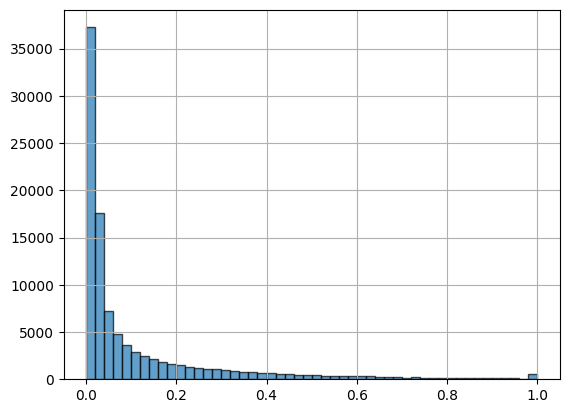

In [38]:
who_what_rated['predicted'].hist(bins=50, edgecolor='black', alpha=0.7)

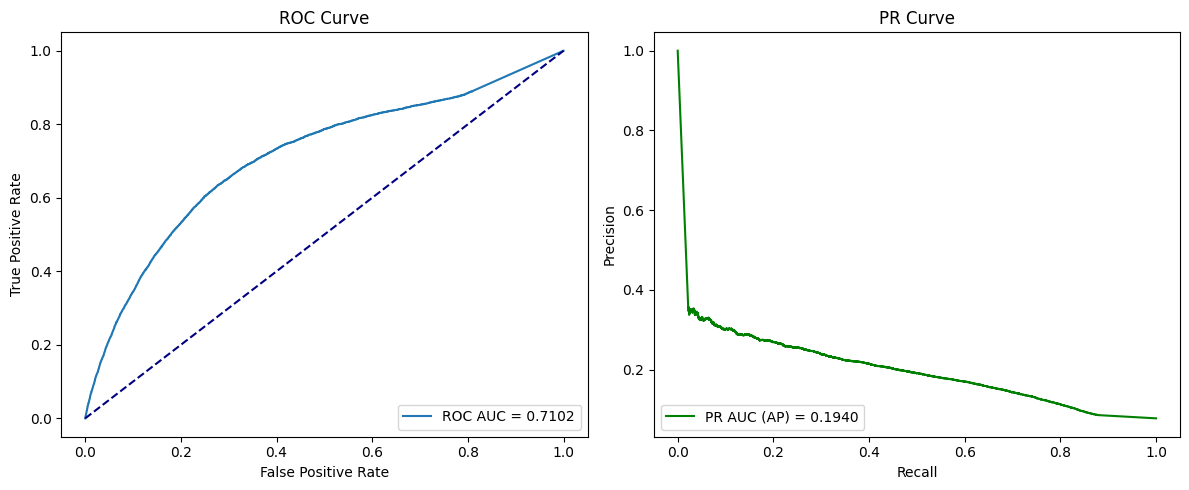

In [39]:
y_scores = who_what_rated['predicted'].values
draw(y_scores)

#### Обучим логистическую регрессию

In [40]:
model_logreg = make_pipeline(
    StandardScaler(), 
    LogisticRegression(class_weight='balanced', solver='lbfgs')
)
model_logreg.fit(X_meta, y_meta)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [41]:
who_what_rated['predicted'] = model_logreg.predict_proba(x_val_features)[:, 1]
who_what_rated[['user_id', 'item_id', 'rating', 'predicted']].sort_values('predicted', ascending=False).head(10)

,user_id,item_id,rating,predicted
18619,89492,8392,0.0,1.0
80810,389254,11606,1.0,1.0
55206,265129,7623,1.0,1.0
64861,310386,1961,1.0,1.0
72886,350357,14998,1.0,1.0
48983,235399,7623,1.0,1.0
73002,350937,16921,1.0,1.0
31276,150094,16921,1.0,1.0
48551,233046,16356,1.0,1.0
44652,213967,11021,0.0,1.0


In [42]:
# rmse = np.sqrt(np.mean((who_what_rated['rating'] - adjust(who_what_rated['predicted'])) ** 2))
rmse = np.sqrt(np.mean((who_what_rated['rating'] - who_what_rated['predicted']*CORRECTION_FACTOR) ** 2))
print(f'Final RMSE: {rmse:.4f}')

Final RMSE: 0.2631


<Axes: >

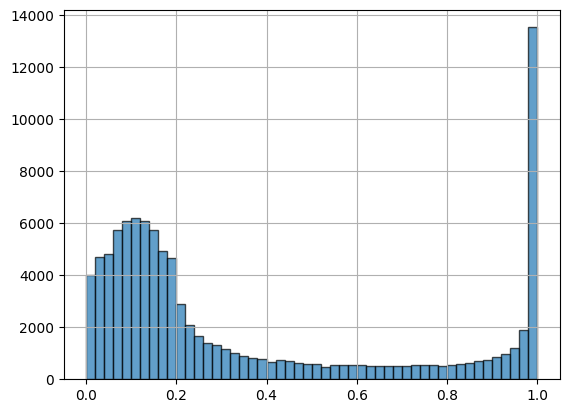

In [43]:
who_what_rated['predicted'].hist(bins=50, edgecolor='black', alpha=0.7)

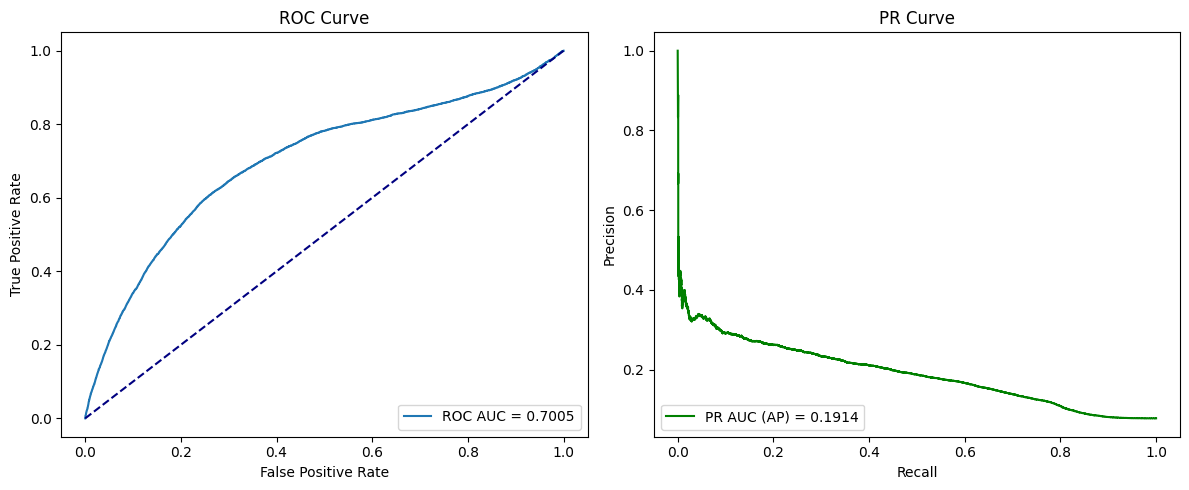

In [44]:
y_scores = who_what_rated['predicted'].values
draw(y_scores)

#### Обучим ансамбль на RMSE

In [45]:
from sklearn.ensemble import HistGradientBoostingRegressor

model_non_linear = HistGradientBoostingRegressor(
    max_iter=100, 
    max_depth=5, 
    l2_regularization=0.2,
)

model_non_linear.fit(X_meta, y_meta)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",5
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.2
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4

In [46]:
who_what_rated['predicted'] = model_non_linear.predict(x_val_features).clip(0, 1)
who_what_rated[['user_id', 'item_id', 'rating', 'predicted']].sort_values('predicted', ascending=False).head(10)

,user_id,item_id,rating,predicted
63446,303470,13422,0.0,0.988036
31276,150094,16921,1.0,0.988036
55206,265129,7623,1.0,0.988036
18619,89492,8392,0.0,0.988036
33928,162441,10357,0.0,0.988036
5522,27486,13254,1.0,0.988036
16060,77323,8595,1.0,0.988036
64861,310386,1961,1.0,0.988036
91625,440268,13254,1.0,0.988036
72886,350357,14998,1.0,0.988036


In [47]:
# rmse = np.sqrt(np.mean((who_what_rated['rating'] - adjust(who_what_rated['predicted'])) ** 2))
rmse = np.sqrt(np.mean((who_what_rated['rating'] - who_what_rated['predicted']*CORRECTION_FACTOR) ** 2))
print(f'Final RMSE: {rmse:.4f}')

Final RMSE: 0.2634


<Axes: >

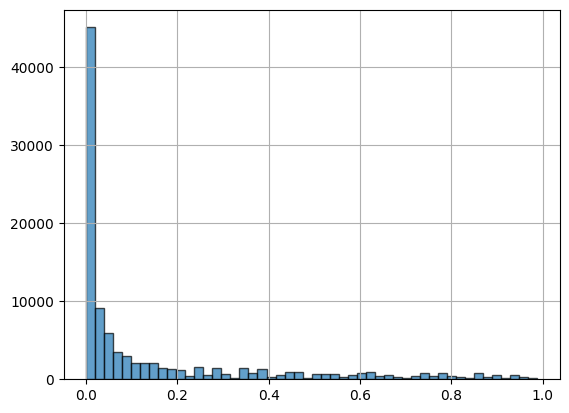

In [48]:
who_what_rated['predicted'].hist(bins=50, edgecolor='black', alpha=0.7)

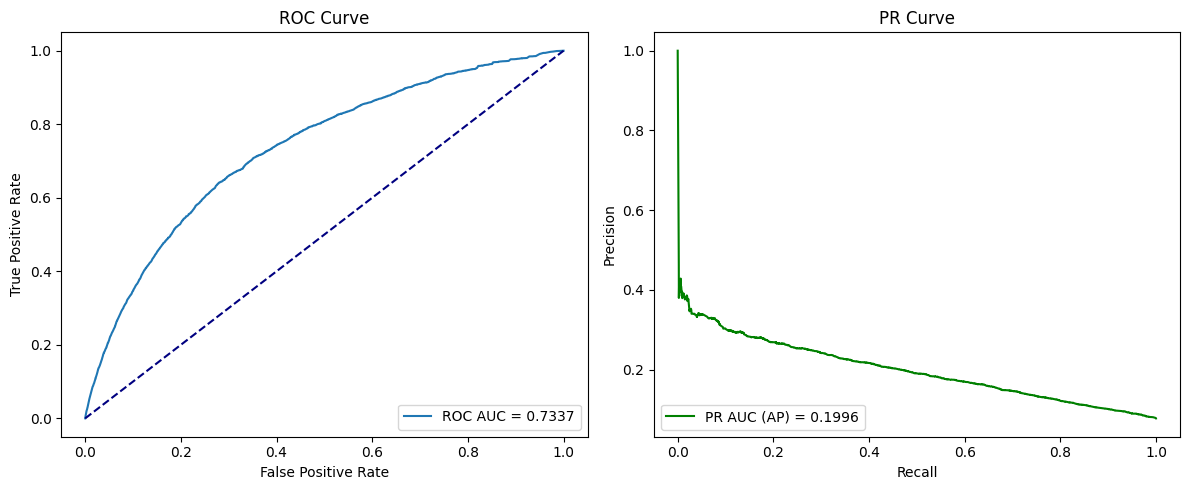

In [49]:
y_scores = who_what_rated['predicted'].values
draw(y_scores)

### Достигнутый показатель RMSE 0.2631 выводит предложенное решение на уровень `2-го` места в историческом зачете соревнования KDD Cup 2007 (Task 1)


---

### 5. Заключение

В ходе выполнения работы была решена задача прогнозирования активности пользователей Netflix «Who Rated What in 2006». Экспериментально подтверждено, что экстремальная разреженность данных делает константный прогноз (Zero Baseline) крайне сильным базовым решением, преодоление которого требует тонкой настройки моделей.

**Основные итоги работы:**
* Изучены и адаптированы методы победителей KDD Cup 2007: использование статистических вероятностей независимости и учет специфики сэмплинга.
* Разработан и реализован пайплайн обучения моделей на признаках, извлеченных из алгоритмов **ALS** и **ELSA**. Сравнение показало, что логистическая регрессия с балансировкой классов в сочетании с пост-калибровкой вероятностей демонстрирует наилучшую точность.
* Итоговое значение **RMSE = 0.2631** значительно превосходит Zero Baseline ($0.2794$) и соответствует уровню топ-решений оригинального соревнования ($0.263$).
* Математически обоснована и успешно применена процедура калибровки предсказаний через отношение глобальной и тренировочной априорных вероятностей, что позволило минимизировать ошибку на несбалансированных тестовых данных.

Результаты работы подтверждают, что интеграция скоров коллаборативной фильтрации в качестве признаков для моделей машинного обучения позволяет эффективно решать задачи классификации в высокоразреженных средах.